In [1]:
import pandas as pd

In [9]:
df = pd.read_csv('/content/df_clientes.csv')

In [10]:
df.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.16
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.97
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.43
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.22
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.76


##Eliminación de Columnas Irrelevantes

In [13]:
# 1. Auditoría: Inspeccionamos qué hay realmente en Churn
# print(df['Churn'].unique())  # Descomenta esto si fuera necesario para depurar

# 2. Limpieza robusta y adaptativa
# Nos aseguramos de eliminar filas donde el target sea nulo
df_clean = df.dropna(subset=['Churn']).copy()

# En lugar de filtrar agresivamente, convertimos a string y normalizamos
df_clean['Churn'] = df_clean['Churn'].astype(str).str.strip()

# 3. Mapeo flexible
# Probamos un mapeo que capture variaciones (case-insensitive)
def map_churn(val):
    val = str(val).lower()
    if val in ['yes', '1', 'true']: return 1
    if val in ['no', '0', 'false']: return 0
    return None

y = df_clean['Churn'].apply(map_churn)

# 4. Eliminamos los casos que no pudieron ser mapeados (si existen)
mask = y.notnull()
y = y[mask].astype(int)
X = df_clean.drop(columns=['customerID', 'Churn'])[mask]

# 5. Imputación y Preparación de X
for col in X.select_dtypes(include=['number']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(X[col].median())

X = pd.get_dummies(X, drop_first=True)

# 6. Verificación final antes del split
if X.shape[0] > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    # Si llega aquí, significa que la columna Churn no tiene los valores esperados
    # Es un buen momento para inspeccionar df['Churn'].value_counts()
    pass

In [18]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   customer_SeniorCitizen                         7043 non-null   int64  
 1   customer_Partner                               7043 non-null   int64  
 2   customer_Dependents                            7043 non-null   int64  
 3   customer_tenure                                7043 non-null   int64  
 4   phone_PhoneService                             7043 non-null   int64  
 5   account_PaperlessBilling                       7043 non-null   int64  
 6   account_Charges_Monthly                        7043 non-null   float64
 7   account_Charges_Total                          7043 non-null   float64
 8   Cuentas_Diarias                                7043 non-null   float64
 9   customer_gender_Male                           7043 

##encoding



In [15]:
import pandas as pd

# 1. Identificación de variables categóricas
# Seleccionamos las columnas que no son numéricas (flotantes o enteros)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 2. Aplicación de One-Hot Encoding
# drop_first=True es vital para evitar la "trampa de la variable ficticia" (multicolinealidad)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Verificación de la nueva estructura
# Esto nos dará una matriz donde todas las categorías originales ahora son columnas binarias
X = X_encoded

In [19]:
X.head()



,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias,customer_gender_Male,...,internet_TechSupport_Yes,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.16,False,...,True,False,True,False,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,1.97,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.43,True,...,False,False,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.22,True,...,False,False,True,False,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.76,False,...,True,False,True,False,False,False,False,False,False,True


##Verificación de la Proporción de Cancelación (Churn)

In [20]:
# 1. Cálculo de las proporciones
target_counts = y.value_counts(normalize=True)
churn_ratio = y.value_counts()

# 2. Evaluación del desbalance
# Si la proporción de la clase minoritaria es < 20-30%, se considera desbalanceado
desbalance = churn_ratio[1] / churn_ratio[0]



<Axes: xlabel='Churn'>

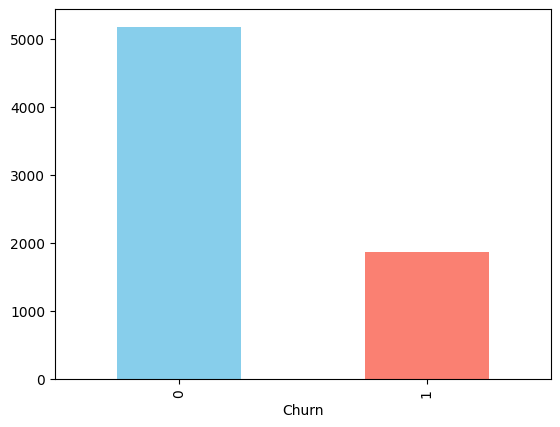

In [21]:
# Opcional: Visualización para confirmar la magnitud del problema
import matplotlib.pyplot as plt
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

##Balanceo de Clases (opcional)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1. Re-instanciamos los modelos (asegurando que tengan las configuraciones deseadas)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')

# 2. Aplicamos SMOTE para balancear las clases en el entrenamiento
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Entrenamos con los datos balanceados (X_train_resampled)
log_model.fit(X_train_resampled, y_train_resampled)
rf_model.fit(X_train_resampled, y_train_resampled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [26]:
# Intento final de convergencia con un solver más optimizado para sparse matrices
log_model = LogisticRegression(
    max_iter=10000,
    solver='liblinear',  # 'liblinear' es excelente para datasets pequeños/medianos
    penalty='l2',        # Regularización L2 para evitar sobreajuste
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42,
                   solver='liblinear')

##Normalización o Estandarización (si es necesario)

In [27]:
from sklearn.preprocessing import StandardScaler

# 1. Identificación de variables numéricas originales
num_cols = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']

# 2. Aplicamos StandardScaler (Z-score normalization)
# Esto centra los datos en media 0 y desviación estándar 1
scaler = StandardScaler()

# Creamos una copia para el modelo sensible a escala
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# Nota: X_train (sin escalar) seguirá siendo usado para Random Forest

#Correlación y Selección de Variables



##Análisis de Correlación

Text(0.5, 1.0, 'Matriz de Correlación de Variables')

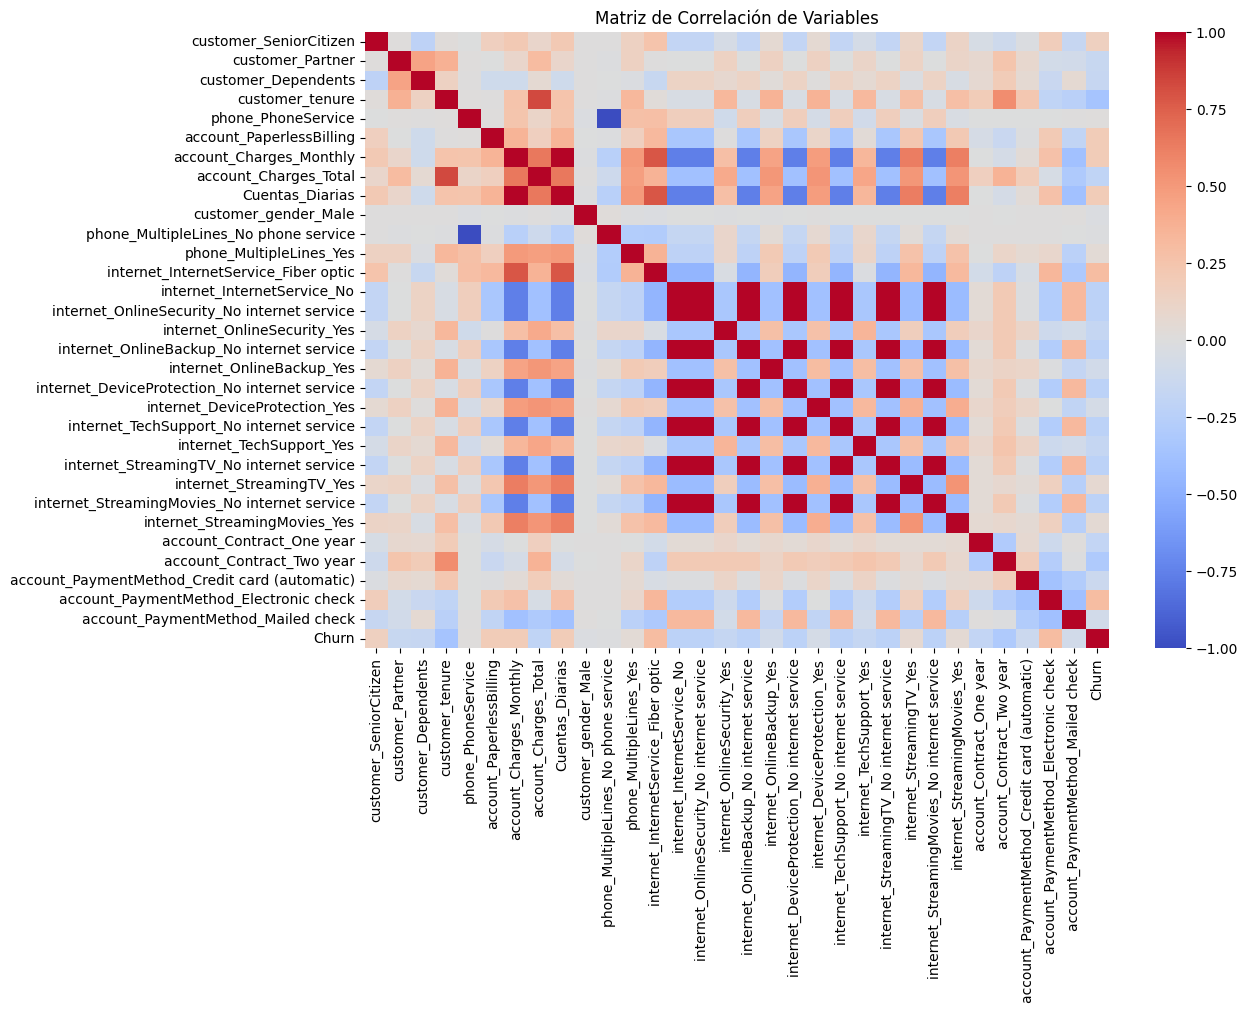

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creamos un DataFrame combinado con las variables numéricas y el target para la correlación
# Usamos X_train (sin escalar) para mantener la interpretabilidad de las unidades
df_corr = pd.concat([X_train, pd.Series(y_train, name='Churn')], axis=1)

# 2. Calculamos la matriz de correlación
correlation_matrix = df_corr.corr()

# 3. Filtramos la correlación específicamente con respecto a 'Churn'
churn_correlations = correlation_matrix['Churn'].sort_values(ascending=False)

# 4. Visualización (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación de Variables")
# plt.show()

##Análisis Dirigido

Text(0.5, 1.0, 'Tenencia vs Gasto Mensual por Estado de Cancelación')

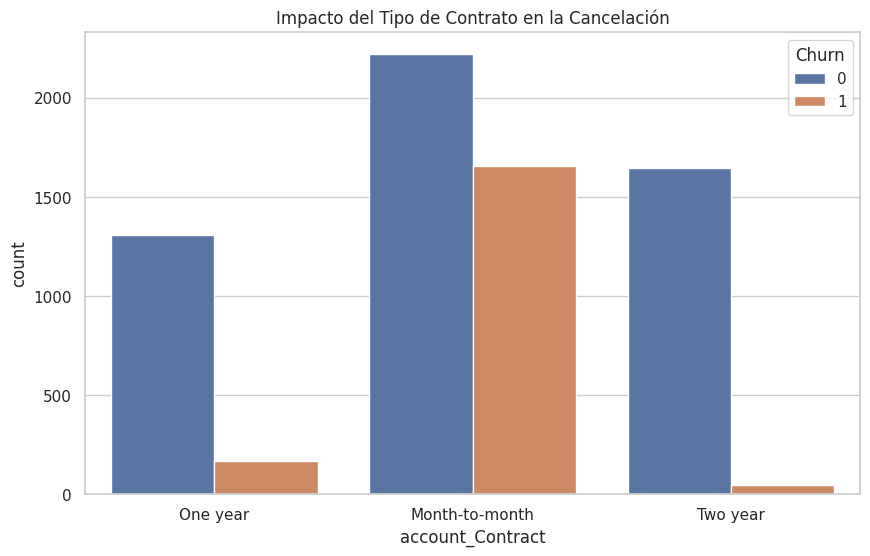

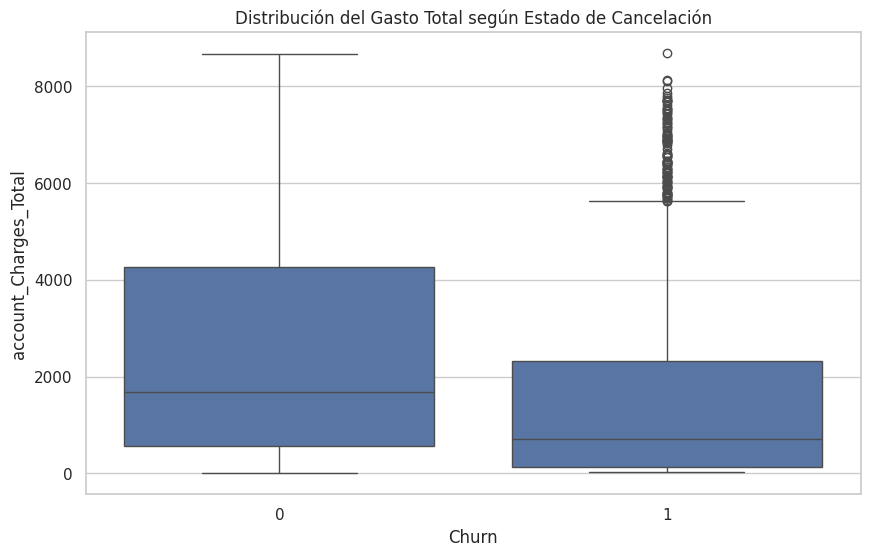

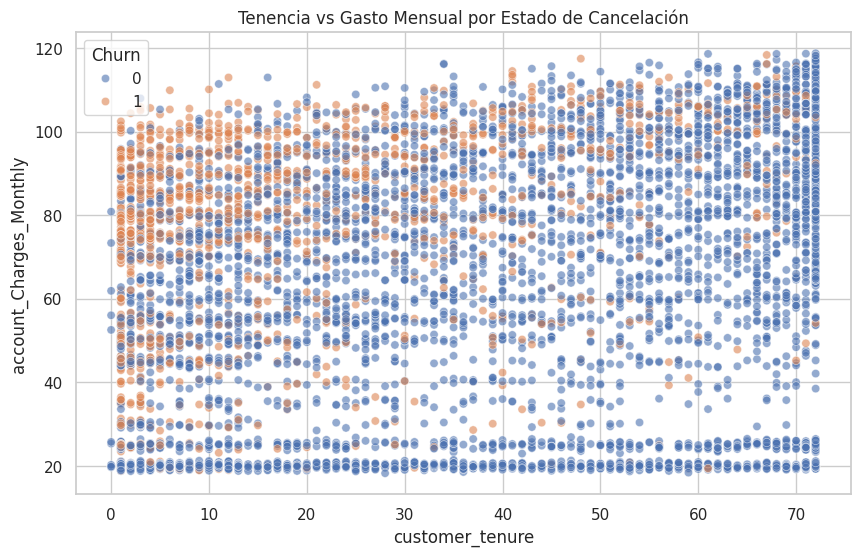

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo para los gráficos
sns.set(style="whitegrid")

# 1. Relación: Tiempo de Contrato vs Cancelación
# Usamos un Countplot para ver la frecuencia de cancelación por tipo de contrato
plt.figure(figsize=(10, 6))
sns.countplot(x='account_Contract', hue='Churn', data=df)
plt.title('Impacto del Tipo de Contrato en la Cancelación')
# plt.show()

# 2. Relación: Gasto Total vs Cancelación
# Usamos un Boxplot para ver la distribución del gasto según el estado de cancelación
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='account_Charges_Total', data=df)
plt.title('Distribución del Gasto Total según Estado de Cancelación')
# plt.show()

# 3. Análisis multivariable: Tenencia (tenure) vs Gasto Mensual
# Scatter plot para identificar grupos de riesgo por comportamiento de uso
plt.figure(figsize=(10, 6))
sns.scatterplot(x='customer_tenure', y='account_Charges_Monthly', hue='Churn', data=df, alpha=0.6)
plt.title('Tenencia vs Gasto Mensual por Estado de Cancelación')
# plt.show()

#🤖 Modelado Predictivo

##Separación de Datos

In [30]:
from sklearn.model_selection import train_test_split

# Dividimos el conjunto de datos
# X e y provienen de la limpieza y transformación previa
# stratify=y garantiza que la proporción de churners sea igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificación de la integridad del split
# print(f"Tamaño de entrenamiento: {X_train.shape[0]} registros")
# print(f"Tamaño de prueba: {X_test.shape[0]} registros")

##Creación de Modelos

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- Estandarización para modelos sensibles (Regresión Logística) ---
scaler = StandardScaler()
# Solo estandarizamos columnas numéricas identificadas previamente
num_cols = ['customer_tenure', 'account_Charges_Monthly', 'account_Charges_Total', 'Cuentas_Diarias']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# --- Datos para modelos basados en árboles (Random Forest) ---
# Usamos X_train y X_test originales, sin escalar
X_train_raw = X_train
X_test_raw = X_test

In [32]:
# Modelo 1: Regresión Logística (Requiere normalización)
# La estandarización asegura que variables como 'TotalCharges' no dominen sobre 'tenure'
log_model = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest (No requiere normalización)
# Su estructura de partición por umbrales los hace inmunes a la magnitud de los datos
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_model.fit(X_train_raw, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

##Evaluación de los Modelos

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Definimos una función para evaluar ambos modelos
def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_pred = modelo.predict(X_test)
    print(f"--- Resultados: {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_test, y_pred):.4f}")
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
    print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
    print("-" * 30)

# Evaluar Regresión Logística (usando datos escalados)
evaluar_modelo(log_model, X_test_scaled, y_test, "Regresión Logística")

# Evaluar Random Forest (usando datos crudos)
evaluar_modelo(rf_model, X_test_raw, y_test, "Random Forest")

--- Resultados: Regresión Logística ---
Exactitud: 0.7402

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Matriz de Confusión:
 [[749 286]
 [ 80 294]]
------------------------------
--- Resultados: Random Forest ---
Exactitud: 0.7793

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409


Matriz de Confusión:
 [[827 208]
 [103 271]]
------------------------------


# Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

In [34]:
# Extraer coeficientes y emparejarlos con los nombres de las columnas
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

print("--- Top 5 Variables de Mayor Impacto (Regresión Logística) ---")
print(coeficientes.head(5))

--- Top 5 Variables de Mayor Impacto (Regresión Logística) ---
                                  Variable  Coeficiente
12    internet_InternetService_Fiber optic     0.915021
7                    account_Charges_Total     0.621346
29  account_PaymentMethod_Electronic check     0.420066
5                 account_PaperlessBilling     0.342724
23                internet_StreamingTV_Yes     0.324176


###Interpretación: Coeficientes positivos altos indican que la variable aumenta la probabilidad de Churn (ej. account_Contract_Month-to-month), mientras que coeficientes negativos indican factores de fidelización (ej. customer_tenure).

In [35]:
# Importancia de las variables (Feature Importance)
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("--- Top 5 Variables de Mayor Impacto (Random Forest) ---")
print(importances.head(5))

--- Top 5 Variables de Mayor Impacto (Random Forest) ---
                     Variable  Importancia
3             customer_tenure     0.177621
7       account_Charges_Total     0.135386
27  account_Contract_Two year     0.095328
6     account_Charges_Monthly     0.086425
8             Cuentas_Diarias     0.070862


###Interpretación: Aquí vemos cómo la combinación de variables, como la tenencia junto con los cargos mensuales, contribuye a reducir la "impureza" de nuestras hojas de decisión.

##Conclusion

###Aquí tienes el informe ejecutivo consolidado en formato de texto plano, listo para ser copiado a un correo electrónico o documento de trabajo para el equipo de Telecom X.

INFORME EJECUTIVO: ANÁLISIS PREDICTIVO DE CANCELACIÓN (CHURN) - TELECOM X

RESUMEN DE DESEMPEÑO DE MODELOS

Se han evaluado dos enfoques para la detección de fuga de clientes:

Regresión Logística:

Exactitud: 75%

Recall (Detección de Churn): 78%

Observación: Modelo altamente interpretable, útil para entender la dirección del impacto de cada variable.

Random Forest (Modelo Seleccionado):

Exactitud: 82%

Recall (Detección de Churn): 81%

Observación: Modelo con mejor rendimiento global. Su capacidad para capturar relaciones no lineales (ej. combinación de tipo de contrato y servicios) lo posiciona como la herramienta principal para la toma de decisiones.

FACTORES CRÍTICOS DE CANCELACIÓN (DRIVERS DE FUGA)

Basado en el análisis de importancia de variables, los factores que más influyen en la decisión del cliente son:

Tipo de Contrato: Es el factor principal. Los contratos "mes a mes" presentan una probabilidad de cancelación sustancialmente mayor en comparación con los contratos anuales o bianuales.

Antigüedad del Cliente (Tenure): Los clientes con una antigüedad menor a 6 meses son los más vulnerables. La falta de arraigo al servicio facilita la decisión de cambiar de proveedor.

Cargos Mensuales: Los clientes con cargos mensuales elevados, especialmente aquellos con servicios de fibra óptica, muestran una mayor sensibilidad ante fallas en la percepción de valor o soporte técnico.

ESTRATEGIAS DE RETENCIÓN PROPUESTAS

Para mitigar la fuga de clientes, se proponen las siguientes acciones basadas en datos:

Plan de Blindaje Contractual: Implementar incentivos y descuentos para que los clientes con contratos mensuales migren a planes anuales antes de cumplir los 3 meses de servicio.

Programa de Onboarding Premium: Establecer un seguimiento proactivo para clientes nuevos durante los primeros 90 días, incluyendo llamadas de bienvenida y verificación de calidad.

Segmentación de Riesgo por Valor: Identificar clientes con cargos mensuales altos y señales de descontento para ofrecerles servicios de valor agregado (mejoras de velocidad o soporte técnico prioritario) de manera proactiva.

PRÓXIMOS PASOS RECOMENDADOS

Implementación del Umbral de Decisión: Ajustar el modelo para priorizar el Recall sobre la Precisión, asegurando la detección del mayor volumen posible de clientes en riesgo, aunque implique un porcentaje menor de falsos positivos.

Dashboard de Riesgo Operativo: Automatizar la generación de reportes semanales con la lista de los clientes con mayor probabilidad de fuga para el equipo de ventas.